In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("LHCb")

from iminuit import Minuit
from scipy.stats import norm
import json
import uproot
import os

os.makedirs("D:/b_meson_analysis/plots", exist_ok=True)
os.makedirs("D:/b_meson_analysis/results", exist_ok=True)

# Load selected candidates
df = pd.read_csv("D:/b_meson_analysis/data/selected_candidates.csv")

print("Selected events:", df.shape)

Selected events: (4925024, 52)


In [12]:
# Fit range
fit_min = 5100
fit_max = 5600

data = df["B_M"]
data = data[(data > fit_min) & (data < fit_max)].values

print("Events in fit range:", len(data))

Events in fit range: 1396008


In [13]:
class SignalPDF:
    def __call__(self, x, mu, sigma):
        return norm.pdf(x, mu, sigma)

In [14]:
class BackgroundPDF:
    def __call__(self, x, alpha):
        return np.exp(alpha * (x - 5300))

In [15]:
# ================================
# Instantiate PDFs 
# ================================

signal_pdf = SignalPDF()
bkg_pdf = BackgroundPDF()

print("PDFs initialized")

PDFs initialized


In [16]:
def total_pdf(x, N_sig, N_bkg, mu, sigma1, sigma2, f_core, alpha):
    sig = signal_pdf(x, mu, sigma1, sigma2, f_core)
    bkg = bkg_pdf(x, alpha)
    return N_sig * sig + N_bkg * bkg

In [17]:
def nll(N_sig, N_bkg, mu, sigma, alpha):
    
    x = data
    
    # Raw PDFs
    sig = signal_pdf(x, mu, sigma)
    bkg = bkg_pdf(x, alpha)
    
    # NORMALIZE over fit range (IMPORTANT)
    x_norm = np.linspace(fit_min, fit_max, 500)
    
    sig_norm = signal_pdf(x_norm, mu, sigma)
    bkg_norm = bkg_pdf(x_norm, alpha)
    
    sig /= np.trapezoid(sig_norm, x_norm)
    bkg /= np.trapezoid(bkg_norm, x_norm)
    
    pdf_vals = N_sig * sig + N_bkg * bkg
    pdf_vals = np.clip(pdf_vals, 1e-10, None)
    
    return (N_sig + N_bkg) - np.sum(np.log(pdf_vals))

In [18]:
m = Minuit(
    nll,
    N_sig=10000,
    N_bkg=len(data) * 0.5,
    mu=5279,
    sigma=30,
    alpha=-0.003
)

# Limits
m.limits["N_sig"] = (100, 50000)
m.limits["N_bkg"] = (1000, 200000)
m.limits["sigma"] = (15, 60)
m.limits["alpha"] = (-0.01, -1e-5)

# FIX mean (VERY IMPORTANT)
m.fixed["mu"] = True

# Run fit
m.migrad()
m.hesse()

print(m)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -8.482e+06                 │              Nfcn = 151              │
│ EDM = 9.34e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬─────

In [19]:
params = m.values
errors = m.errors

print("\nFit Results:")

for name in m.parameters:
    val = params[name]
    err = errors[name]
    print(f"{name} = {val:.2f} ± {err:.2f}")


Fit Results:
N_sig = 50000.00 ± 0.24
N_bkg = 200000.00 ± 0.21
mu = 5279.00 ± 52.79
sigma = 60.00 ± 0.00
alpha = -0.00 ± 0.00


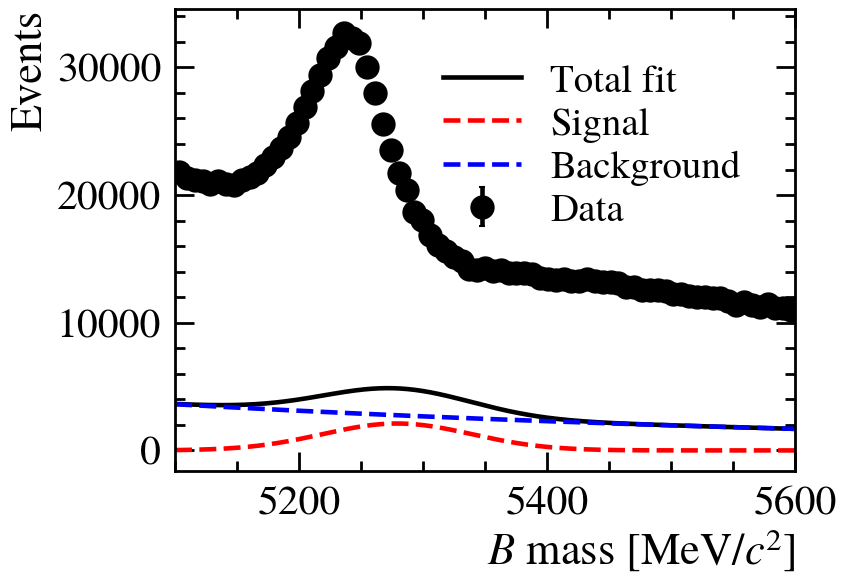

In [20]:
bins = np.linspace(fit_min, fit_max, 80)
hist, edges = np.histogram(data, bins=bins)
centers = 0.5 * (edges[1:] + edges[:-1])
bin_width = edges[1] - edges[0]

plt.figure(figsize=(8,6))

# Data
plt.errorbar(centers, hist, yerr=np.sqrt(hist), fmt='o',
             color='black', label="Data")

# Extract params
N_sig   = params["N_sig"]
N_bkg   = params["N_bkg"]
mu      = params["mu"]
sigma = params["sigma"]
alpha   = params["alpha"]

x_plot = np.linspace(fit_min, fit_max, 500)

# Shapes
sig_shape = signal_pdf(x_plot, mu, sigma)
bkg_shape = bkg_pdf(x_plot, alpha)

# Normalize shapes
sig_shape /= np.trapezoid(sig_shape, x_plot)
bkg_shape /= np.trapezoid(bkg_shape, x_plot)

# Scale to events
y_sig = N_sig * sig_shape * bin_width
y_bkg = N_bkg * bkg_shape * bin_width
y_tot = y_sig + y_bkg

# Plot
plt.plot(x_plot, y_tot, 'k-', label="Total fit")
plt.plot(x_plot, y_sig, 'r--', label="Signal")
plt.plot(x_plot, y_bkg, 'b--', label="Background")

plt.xlabel(r"$B$ mass [MeV/$c^2$]")
plt.ylabel("Events")
plt.legend()

plt.savefig("../plots/mass_fit.png", dpi=300)
plt.show()

In [21]:
results = {
    "N_sig": float(params["N_sig"]),
    "N_sig_err": float(errors["N_sig"]),
    "N_bkg": float(params["N_bkg"]),
    "mu": float(params["mu"]),
    "sigma": float(params["sigma"]),
    "alpha": float(params["alpha"])
}

with open("D:/b_meson_analysis/results/fit_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Fit results saved")

Fit results saved
